In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv("data.csv")
if "Unnamed:0" in df.columns:
    df.drop("Unnamed:0",axis=1,inplace=True)
print("Dataset Preview:\n")
print(df.head())

Dataset Preview:

   Unnamed: 0       Dates  Andhra Pradesh  Arunachal Pradesh  Assam  Bihar  \
0           0  06-01-2013           251.5                1.6   21.3   40.9   
1           1  07-01-2013           257.9                1.7   21.2   39.6   
2           2  08-01-2013           265.1                1.6   20.4   39.2   
3           3  09-01-2013           261.0                1.6   21.4   39.5   
4           4  10-01-2013           260.0                1.6   21.1   39.7   

   Chandigarh  Chhattisgarh   DD  Delhi  ...  Punjab  Rajasthan  Sikkim  \
0         3.8          60.3  5.8   66.0  ...    95.2      192.0     1.7   
1         3.8          64.3  5.8   67.2  ...    92.8      192.9     1.8   
2         3.9          63.0  5.9   66.7  ...    93.9      197.1     1.8   
3         3.7          65.0  5.8   67.4  ...    90.1      197.6     1.9   
4         3.8          66.5  5.9   67.8  ...    93.5      199.9     1.9   

   Tamil Nadu  Telangana  Tripura     UP  Uttarakhand  West Be

In [23]:
df["Dates"]=pd.to_datetime(df["Dates"],dayfirst=True)
numeric_df=df.select_dtypes(include=np.number)
total=df["Total Consumption"].values
state_columns=numeric_df.drop("Total Consumption",axis=1).columns
state_data=numeric_df.drop("Total Consumption",axis=1).values

In [25]:
print("\n🔹 BASIC ANALYSIS\n")
print("Total Consumption:",np.sum(total))
print("Average Consumption:",np.mean(total))
print("Maximum Consumption:",np.max(total))
print("MInimum Consumption:",np.min(total))
print("Standard Deviation:",np.std(total))


 🔹 BASIC ANALYSIS

Total Consumption: nan
Average Consumption: nan
Maximum Consumption: nan
MInimum Consumption: nan
Standard Deviation: nan


In [27]:
peak_index=np.argmax(total)
print("\n🔹 PEAK DAY\n")
print("Peak Date:",df["Dates"][peak_index])
print("Peak Value:",total[peak_index])


🔹 PEAK DAY

Peak Date: 2023-04-24 00:00:00
Peak Value: nan


In [29]:
daily_change=np.diff(total)
print("\n🔹 DAILY CHANGE (First 10)\n")
print(daily_change[:10])


🔹 DAILY CHANGE (First 10)

[ 31.   46.3 -10.9   8.7 -37.9 -44.6 -17.8  10.9  24.3  -5.3]


In [33]:
state_avg=np.mean(state_data,axis=0)
max_state_index=np.argmax(state_avg)
min_state_index=np.argmin(state_avg)
print("\n🔹 STATE ANALYSIS\n")
print("Highest Avg Consumption State:",state_columns[max_state_index])
print("Lowest Avg Consumption State:",state_columns[min_state_index])


🔹 STATE ANALYSIS

Highest Avg Consumption State: DD
Lowest Avg Consumption State: DD


In [37]:
top5_indices=np.argsort(total)[-5:]
print("\n🔹 TOP 5 CONSUMPTION DAYS\n")
for i in top5_indices:
    print(df["Dates"][i],"->",total[i])


🔹 TOP 5 CONSUMPTION DAYS

2023-04-27 00:00:00 -> nan
2023-04-28 00:00:00 -> nan
2023-04-29 00:00:00 -> nan
2023-04-25 00:00:00 -> nan
2023-04-26 00:00:00 -> nan


In [39]:
df["Month"]=df["Dates"].dt.month
monthly_avg=df.groupby("Month")["Total Consumption"].mean()
print("\n🔹 MONTHLY AVERAGE CONSUMPTION\n")
print(monthly_avg)


🔹 MONTHLY AVERAGE CONSUMPTION

Month
1     3364.314591
2     3498.726877
3     3531.358246
4     3663.832107
5     3716.000613
6     3829.585570
7     3694.029118
8     3726.430725
9     3706.444311
10    3425.361890
11    3217.619436
12    3225.578157
Name: Total Consumption, dtype: float64


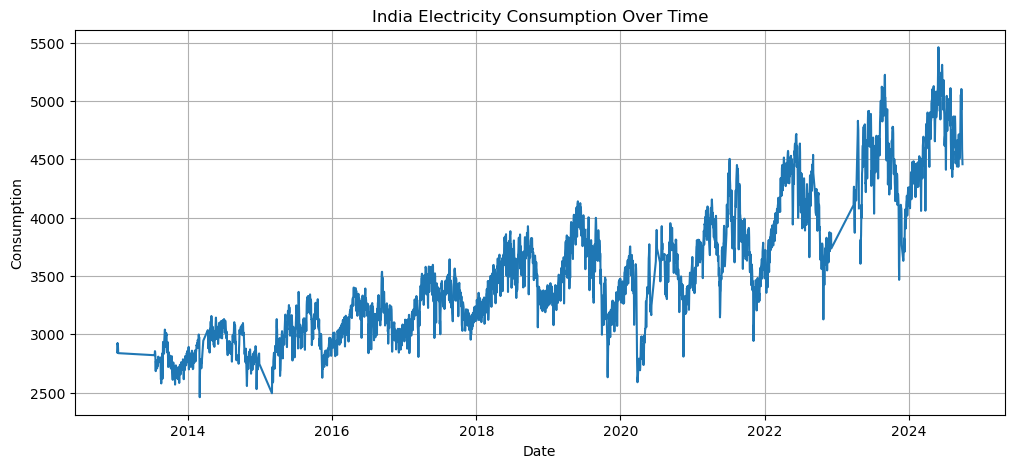

In [41]:
plt.figure(figsize=(12,5))
plt.plot(df["Dates"],total)
plt.title("India Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.grid()
plt.show()

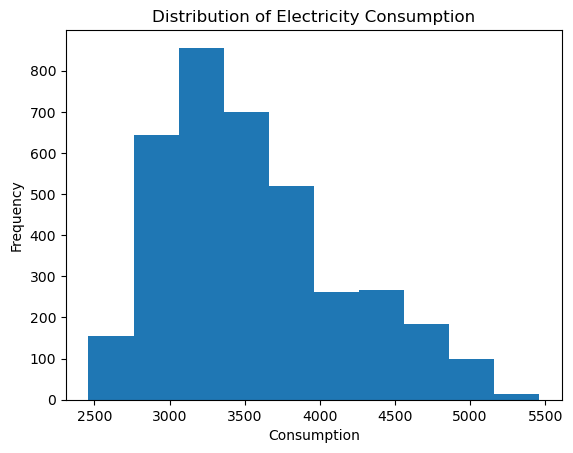

In [43]:
plt.figure()
plt.hist(total)
plt.title("Distribution of Electricity Consumption")
plt.xlabel("Consumption")
plt.ylabel("Frequency")
plt.show()

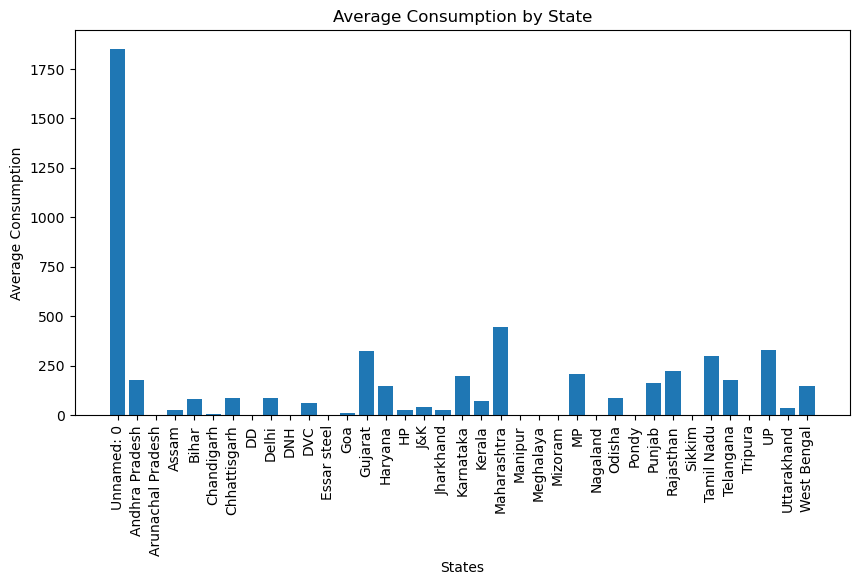

In [45]:
plt.figure(figsize=(10,5))
plt.bar(state_columns,state_avg)
plt.title("Average Consumption by State")
plt.xlabel("States")
plt.ylabel("Average Consumption")
plt.xticks(rotation=90)
plt.show()

In [ ]:
print("\n🔹 INSIGHTS\n")
print("• Electricity usage varies significantly across time.")
print("• Peak consumption occurs on:", df['Dates'][peak_index])
print("• Highest consuming state:", state_columns[max_state_index])
print("• Lowest consuming state:", state_columns[min_state_index])
print("• Seasonal trends visible in monthly averages.")